# Polymarket Data Exploration

Exploring the collected Polymarket markets and trades data.

In [1]:
import duckdb
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120

base = Path('data/polymarket')
con = duckdb.connect()

markets = con.execute(f"SELECT * FROM '{base / 'markets' / '*.parquet'}'").df()
trades = con.execute(f"SELECT * FROM '{base / 'trades' / '*.parquet'}'").df()
print(f'Markets: {len(markets):,} rows | Trades: {len(trades):,} rows')
print(f'Total market volume: ${markets["volume"].sum():,.0f}')

Markets: 420,585 rows | Trades: 715,489 rows
Total market volume: $50,569,939,969


## 1. Market Growth Over Time

/var/folders/k7/8tp3r0m54sv0h01_w0ttqdzr0000gn/T/ipykernel_48829/1368883418.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  markets['created_month'] = markets['created_at'].dt.to_period('M')


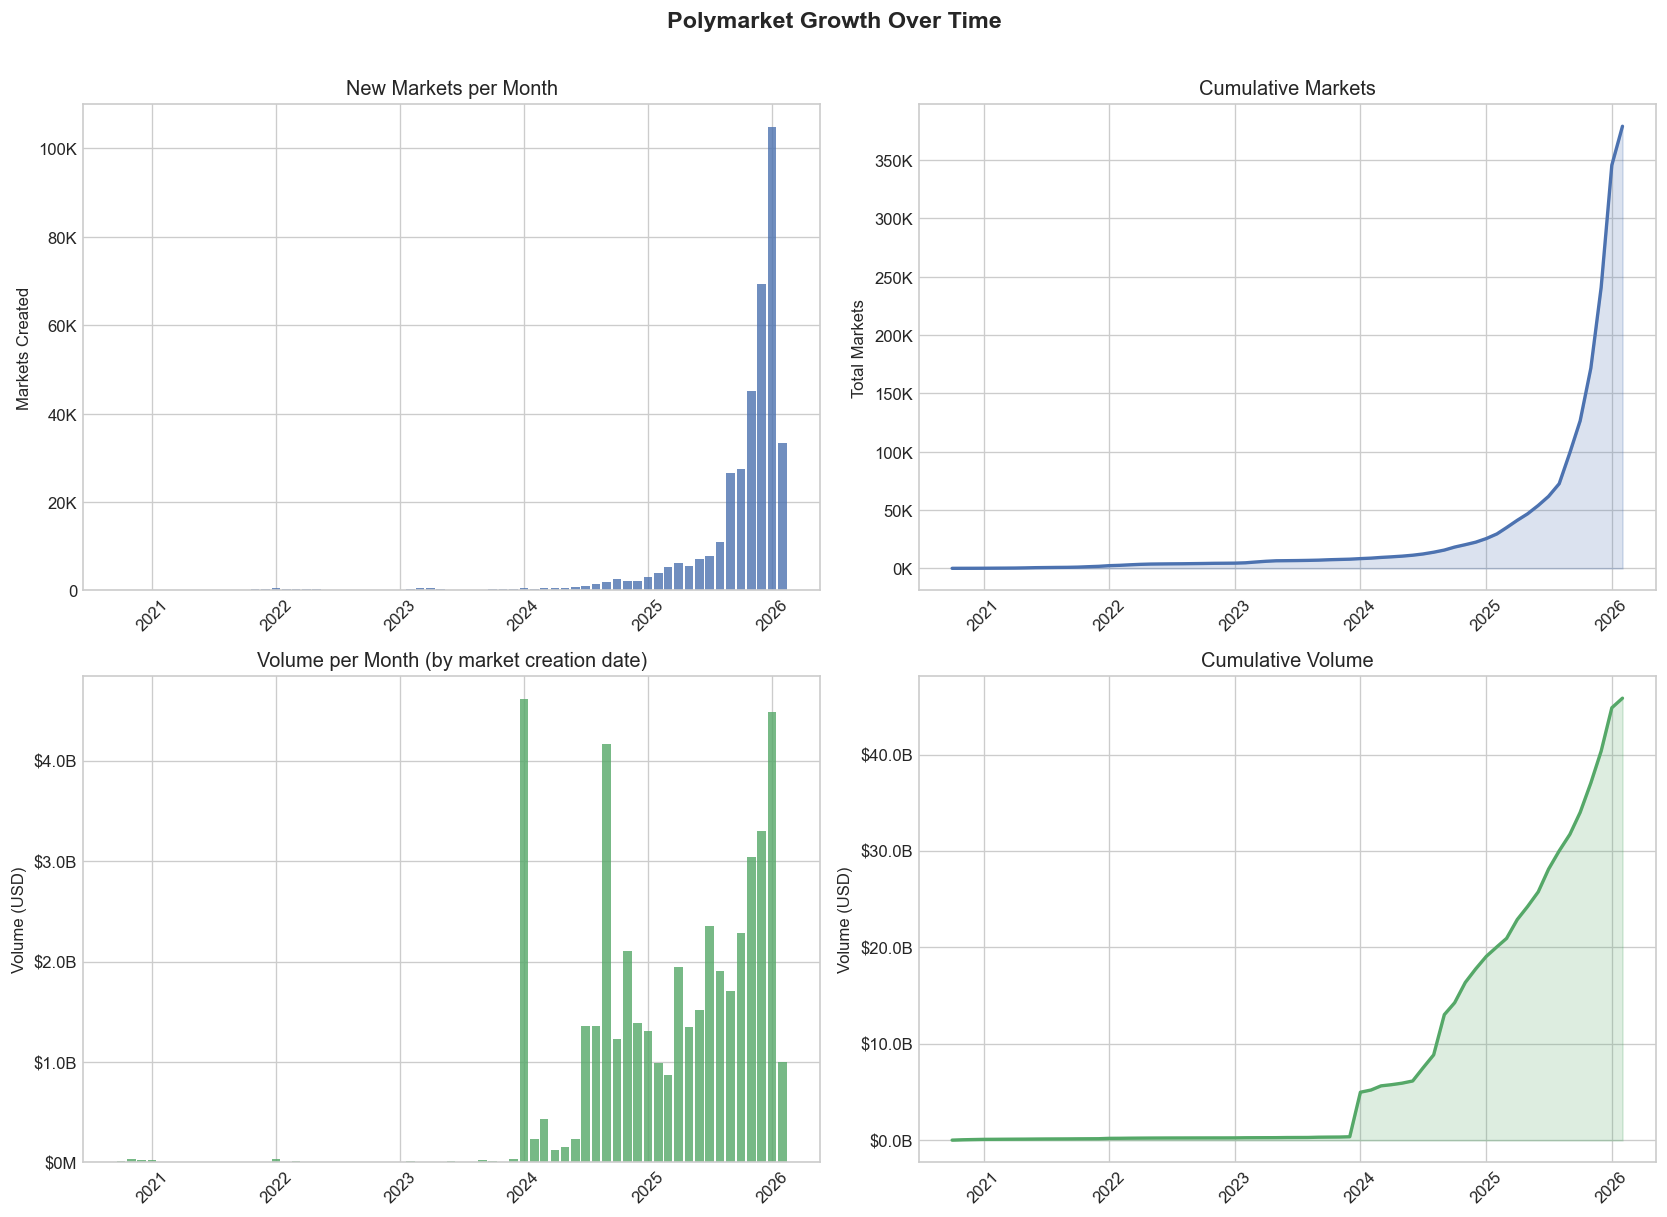

In [2]:
# Markets created per month and cumulative volume
markets['created_month'] = markets['created_at'].dt.to_period('M')
monthly = markets.dropna(subset=['created_at']).groupby('created_month').agg(
    count=('id', 'count'),
    volume=('volume', 'sum')
).reset_index()
monthly['created_month'] = monthly['created_month'].dt.to_timestamp()
monthly['cumulative_volume'] = monthly['volume'].cumsum()
monthly['cumulative_markets'] = monthly['count'].cumsum()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# New markets per month
ax = axes[0, 0]
ax.bar(monthly['created_month'], monthly['count'], width=25, color='#4C72B0', alpha=0.8)
ax.set_title('New Markets per Month')
ax.set_ylabel('Markets Created')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K' if x >= 1000 else f'{x:.0f}'))

# Cumulative markets
ax = axes[0, 1]
ax.plot(monthly['created_month'], monthly['cumulative_markets'], color='#4C72B0', linewidth=2)
ax.fill_between(monthly['created_month'], monthly['cumulative_markets'], alpha=0.2, color='#4C72B0')
ax.set_title('Cumulative Markets')
ax.set_ylabel('Total Markets')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Volume per month
ax = axes[1, 0]
ax.bar(monthly['created_month'], monthly['volume'], width=25, color='#55A868', alpha=0.8)
ax.set_title('Volume per Month (by market creation date)')
ax.set_ylabel('Volume (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e9:.1f}B' if x >= 1e9 else f'${x/1e6:.0f}M'))

# Cumulative volume
ax = axes[1, 1]
ax.plot(monthly['created_month'], monthly['cumulative_volume'], color='#55A868', linewidth=2)
ax.fill_between(monthly['created_month'], monthly['cumulative_volume'], alpha=0.2, color='#55A868')
ax.set_title('Cumulative Volume')
ax.set_ylabel('Volume (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e9:.1f}B'))

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Polymarket Growth Over Time', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 2. Market Volume Distribution

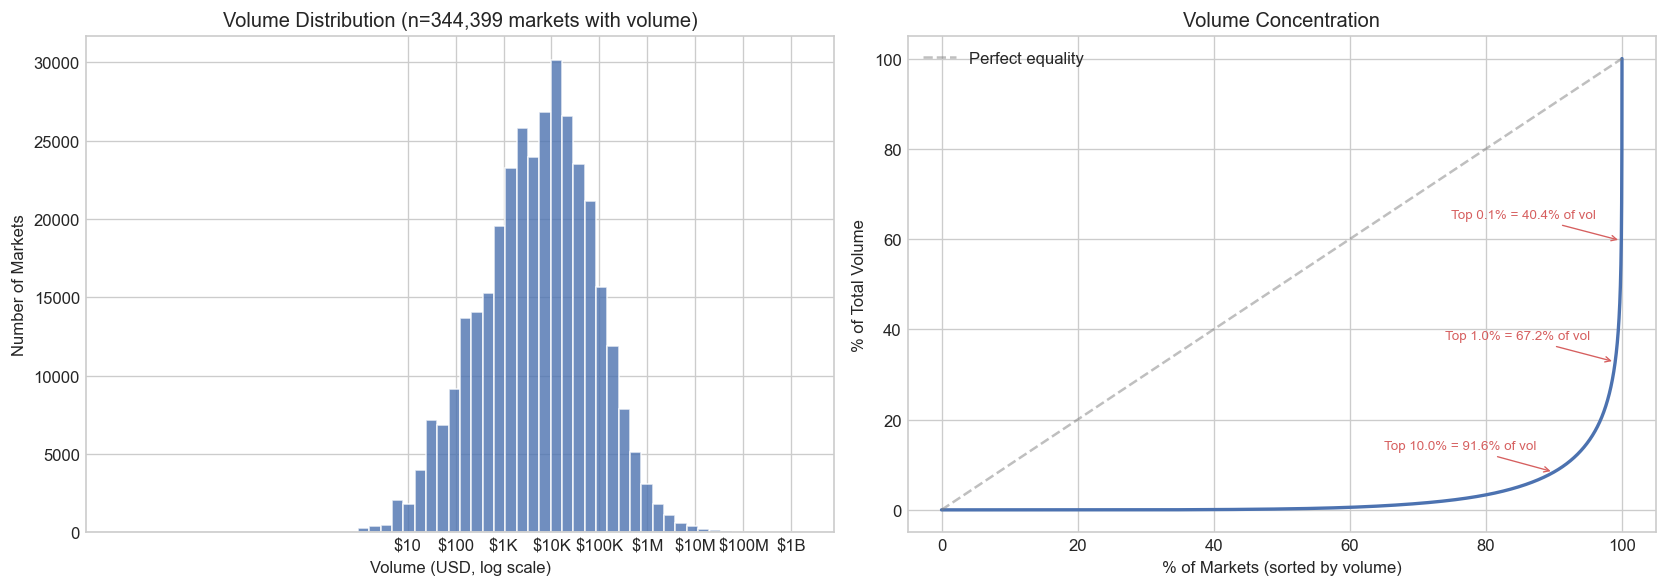


Zero-volume markets: 76,186 (18.1%)
Median volume: $2,616
Mean volume: $120,237
Top 1% volume threshold: $1,372,223


In [3]:
# Volume distribution (log scale)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of volume (log scale)
ax = axes[0]
nonzero_vol = markets[markets['volume'] > 0]['volume']
ax.hist(np.log10(nonzero_vol), bins=60, color='#4C72B0', alpha=0.8, edgecolor='white')
ax.set_xlabel('Volume (USD, log scale)')
ax.set_ylabel('Number of Markets')
ax.set_title(f'Volume Distribution (n={len(nonzero_vol):,} markets with volume)')
ticks = [1, 2, 3, 4, 5, 6, 7, 8, 9]
ax.set_xticks(ticks)
ax.set_xticklabels(['$10', '$100', '$1K', '$10K', '$100K', '$1M', '$10M', '$100M', '$1B'])

# Volume concentration (Lorenz-like)
ax = axes[1]
sorted_vol = markets['volume'].sort_values().values
cumvol = np.cumsum(sorted_vol) / sorted_vol.sum()
pct = np.arange(1, len(sorted_vol) + 1) / len(sorted_vol)
ax.plot(pct * 100, cumvol * 100, color='#4C72B0', linewidth=2)
ax.plot([0, 100], [0, 100], '--', color='gray', alpha=0.5, label='Perfect equality')
ax.set_xlabel('% of Markets (sorted by volume)')
ax.set_ylabel('% of Total Volume')
ax.set_title('Volume Concentration')

# Annotate key percentiles
for p in [90, 99, 99.9]:
    idx = int(p / 100 * len(sorted_vol))
    vol_pct = cumvol[idx] * 100
    ax.annotate(f'Top {100-p:.1f}% = {100-vol_pct:.1f}% of vol',
                xy=(p, vol_pct), fontsize=8, color='#D65F5F',
                arrowprops=dict(arrowstyle='->', color='#D65F5F', lw=0.8),
                xytext=(p - 25, vol_pct + 5))

ax.legend()

plt.tight_layout()
plt.show()

# Print key stats
print(f'\nZero-volume markets: {(markets["volume"] == 0).sum():,} ({100*(markets["volume"]==0).mean():.1f}%)')
print(f'Median volume: ${markets["volume"].median():,.0f}')
print(f'Mean volume: ${markets["volume"].mean():,.0f}')
print(f'Top 1% volume threshold: ${markets["volume"].quantile(0.99):,.0f}')

## 3. Market Resolution Analysis

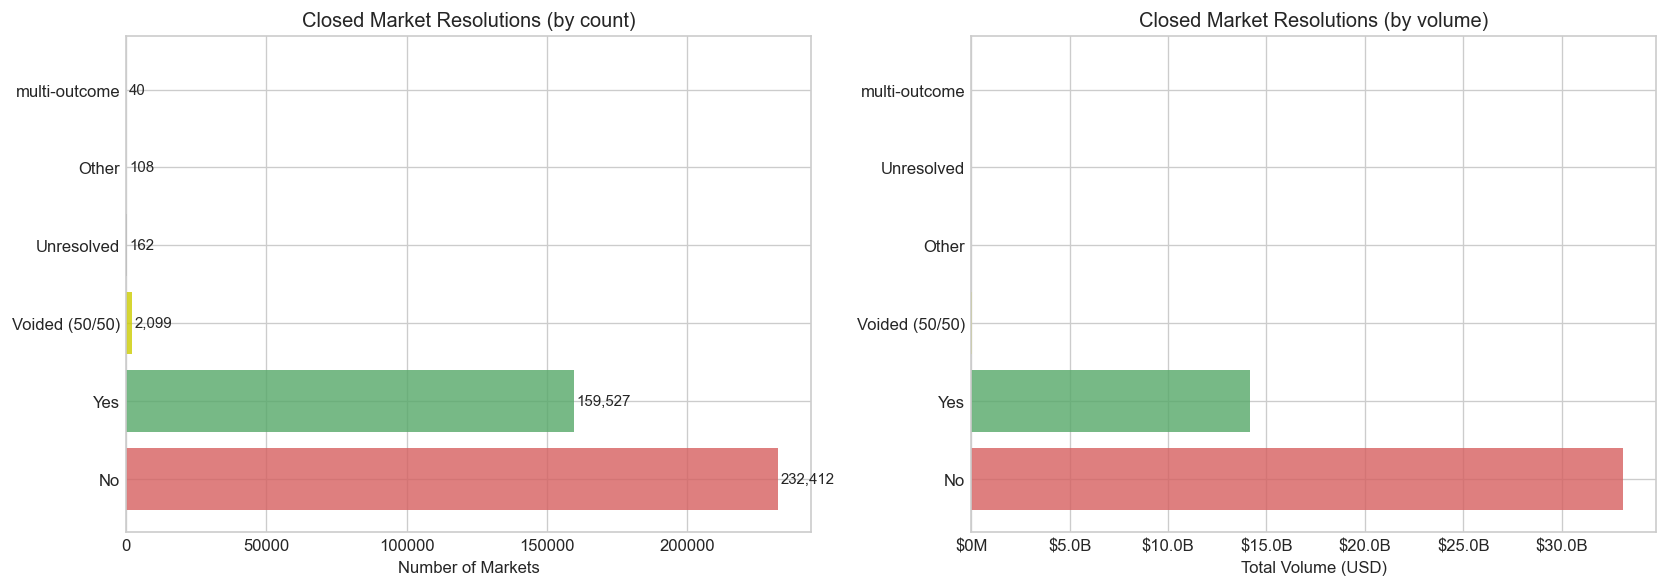


Binary resolved markets: 391,939
  Yes wins: 159,527 (40.7%)
  No wins:  232,412 (59.3%)


In [4]:
# Parse resolution outcomes
def get_resolution(outcome_prices_str):
    try:
        prices = json.loads(outcome_prices_str) if outcome_prices_str else None
        if not prices or len(prices) != 2:
            return 'multi-outcome'
        p0, p1 = float(prices[0]), float(prices[1])
        if p0 > 0.99 and p1 < 0.01:
            return 'Yes'
        elif p0 < 0.01 and p1 > 0.99:
            return 'No'
        elif abs(p0 - 0.5) < 0.01 and abs(p1 - 0.5) < 0.01:
            return 'Voided (50/50)'
        elif p0 == 0 and p1 == 0:
            return 'Unresolved'
        else:
            return 'Other'
    except:
        return 'Parse error'

closed = markets[markets['closed'] == True].copy()
closed['resolution'] = closed['outcome_prices'].apply(get_resolution)

resolution_counts = closed['resolution'].value_counts()
resolution_vol = closed.groupby('resolution')['volume'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Resolution counts
ax = axes[0]
colors = {'Yes': '#55A868', 'No': '#D65F5F', 'Voided (50/50)': '#CCCC00', 'Other': '#999999', 'Unresolved': '#777777', 'multi-outcome': '#8172B2', 'Parse error': '#333333'}
res_colors = [colors.get(x, '#999999') for x in resolution_counts.index]
bars = ax.barh(resolution_counts.index, resolution_counts.values, color=res_colors, alpha=0.8)
ax.set_xlabel('Number of Markets')
ax.set_title('Closed Market Resolutions (by count)')
for bar, val in zip(bars, resolution_counts.values):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)

# Resolution volume
ax = axes[1]
res_vol_colors = [colors.get(x, '#999999') for x in resolution_vol.index]
bars = ax.barh(resolution_vol.index, resolution_vol.values, color=res_vol_colors, alpha=0.8)
ax.set_xlabel('Total Volume (USD)')
ax.set_title('Closed Market Resolutions (by volume)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e9:.1f}B' if x >= 1e9 else f'${x/1e6:.0f}M'))

plt.tight_layout()
plt.show()

# Yes vs No rate
yes_count = resolution_counts.get('Yes', 0)
no_count = resolution_counts.get('No', 0)
total_binary = yes_count + no_count
print(f'\nBinary resolved markets: {total_binary:,}')
print(f'  Yes wins: {yes_count:,} ({100*yes_count/total_binary:.1f}%)')
print(f'  No wins:  {no_count:,} ({100*no_count/total_binary:.1f}%)')

## 4. Trade-Level Analysis

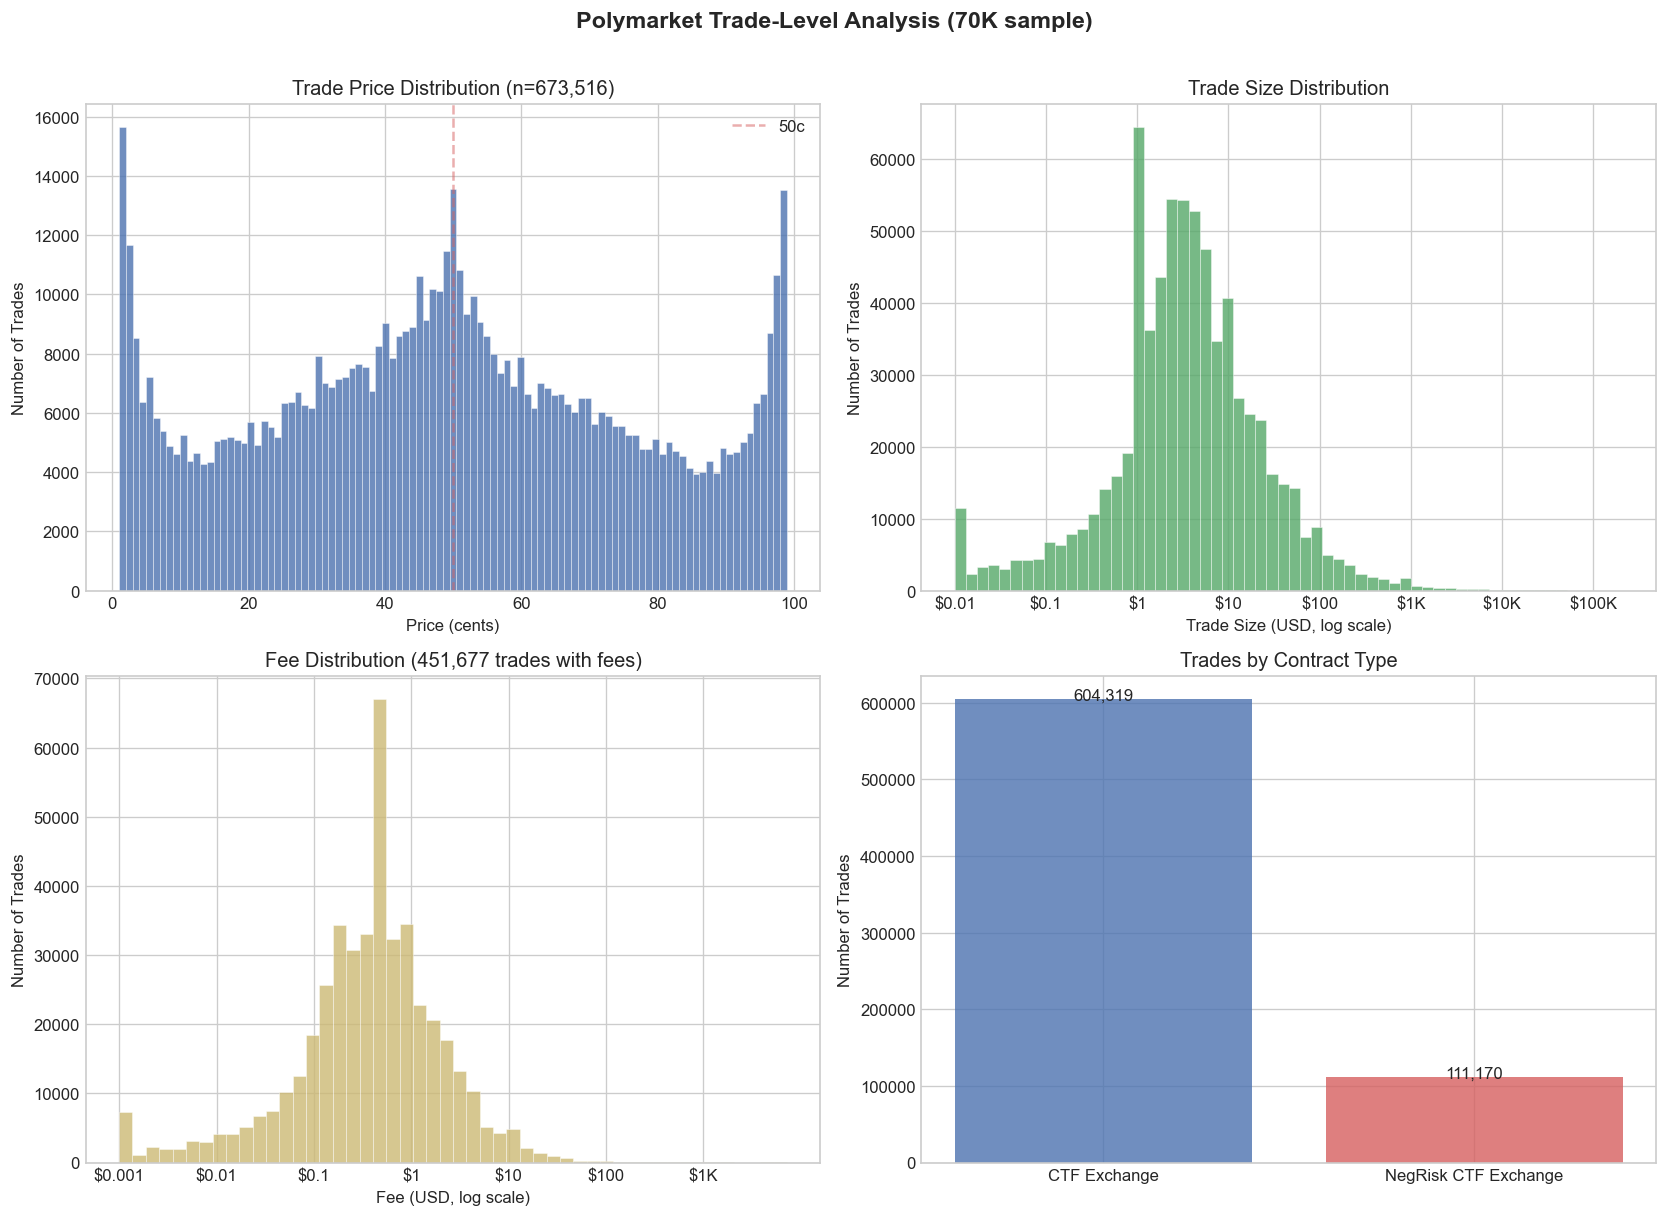


Trade stats:
  Median trade size: $3.25
  Mean trade size: $32.66
  Total volume in sample: $23,364,872
  Trades with zero fee: 263,812 (36.9%)
  Avg fee (when >0): $1.42


In [5]:
# Compute trade prices and sizes
trade_analysis = con.execute(f"""
    SELECT 
        CASE 
            WHEN maker_asset_id = '0' THEN maker_amount::DOUBLE / NULLIF(taker_amount::DOUBLE, 0)
            ELSE taker_amount::DOUBLE / NULLIF(maker_amount::DOUBLE, 0)
        END AS price,
        CASE 
            WHEN maker_asset_id = '0' THEN maker_amount::DOUBLE / 1e6
            ELSE taker_amount::DOUBLE / 1e6
        END AS usdc_amount,
        fee::DOUBLE / 1e6 AS fee_usd,
        _contract
    FROM '{base / 'trades' / '*.parquet'}'
    WHERE taker_amount > 0 AND maker_amount > 0
""").df()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Price distribution
ax = axes[0, 0]
valid_prices = trade_analysis[(trade_analysis['price'] >= 0.01) & (trade_analysis['price'] <= 0.99)]
ax.hist(valid_prices['price'] * 100, bins=99, color='#4C72B0', alpha=0.8, edgecolor='white', linewidth=0.3)
ax.set_xlabel('Price (cents)')
ax.set_ylabel('Number of Trades')
ax.set_title(f'Trade Price Distribution (n={len(valid_prices):,})')
ax.axvline(50, color='#D65F5F', linestyle='--', alpha=0.5, label='50c')
ax.legend()

# Trade size distribution
ax = axes[0, 1]
nonzero_amt = trade_analysis[trade_analysis['usdc_amount'] > 0]['usdc_amount']
ax.hist(np.log10(nonzero_amt.clip(lower=0.01)), bins=60, color='#55A868', alpha=0.8, edgecolor='white', linewidth=0.3)
ax.set_xlabel('Trade Size (USD, log scale)')
ax.set_ylabel('Number of Trades')
ax.set_title('Trade Size Distribution')
ticks = [-2, -1, 0, 1, 2, 3, 4, 5]
ax.set_xticks(ticks)
ax.set_xticklabels(['$0.01', '$0.1', '$1', '$10', '$100', '$1K', '$10K', '$100K'])

# Fee distribution
ax = axes[1, 0]
fees = trade_analysis[trade_analysis['fee_usd'] > 0]['fee_usd']
if len(fees) > 0:
    ax.hist(np.log10(fees.clip(lower=0.001)), bins=50, color='#CCB974', alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.set_xlabel('Fee (USD, log scale)')
    ax.set_ylabel('Number of Trades')
    ax.set_title(f'Fee Distribution ({len(fees):,} trades with fees)')
    ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
    ax.set_xticklabels(['$0.001', '$0.01', '$0.1', '$1', '$10', '$100', '$1K'])
else:
    ax.text(0.5, 0.5, 'No fees in sample', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Fee Distribution')

# CTF Exchange vs NegRisk
ax = axes[1, 1]
contract_counts = trade_analysis['_contract'].value_counts()
ax.bar(contract_counts.index, contract_counts.values, color=['#4C72B0', '#D65F5F'], alpha=0.8)
ax.set_ylabel('Number of Trades')
ax.set_title('Trades by Contract Type')
for i, (label, val) in enumerate(contract_counts.items()):
    ax.text(i, val + 200, f'{val:,}', ha='center', fontsize=10)

plt.suptitle('Polymarket Trade-Level Analysis (70K sample)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'\nTrade stats:')
print(f'  Median trade size: ${trade_analysis["usdc_amount"].median():,.2f}')
print(f'  Mean trade size: ${trade_analysis["usdc_amount"].mean():,.2f}')
print(f'  Total volume in sample: ${trade_analysis["usdc_amount"].sum():,.0f}')
print(f'  Trades with zero fee: {(trade_analysis["fee_usd"] == 0).sum():,} ({100*(trade_analysis["fee_usd"]==0).mean():.1f}%)')
print(f'  Avg fee (when >0): ${fees.mean() if len(fees) > 0 else 0:,.2f}')

## 5. Maker/Taker Network Analysis

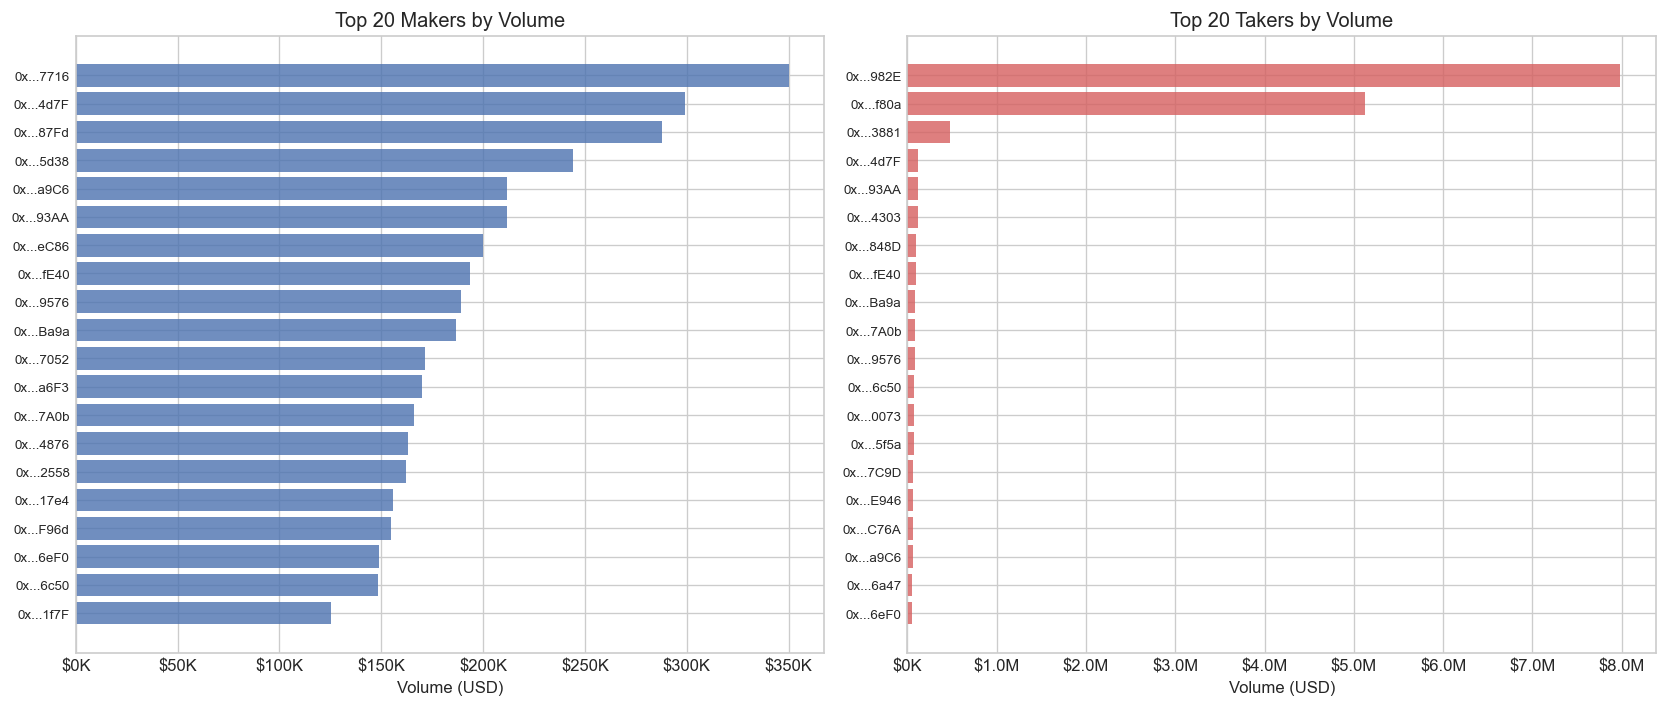


Maker concentration:
  Unique makers: 27,302
  Top 10 makers: $2,374,230 (10.2% of volume)
  Top maker: $350,000 (1.5% of volume)


In [6]:
# Top makers and takers by volume
maker_vol = con.execute(f"""
    SELECT 
        maker,
        COUNT(*) as trade_count,
        SUM(CASE WHEN maker_asset_id = '0' THEN maker_amount ELSE taker_amount END)::DOUBLE / 1e6 AS total_usdc
    FROM '{base / 'trades' / '*.parquet'}'
    WHERE taker_amount > 0 AND maker_amount > 0
    GROUP BY maker
    ORDER BY total_usdc DESC
    LIMIT 20
""").df()

taker_vol = con.execute(f"""
    SELECT 
        taker,
        COUNT(*) as trade_count,
        SUM(CASE WHEN maker_asset_id = '0' THEN maker_amount ELSE taker_amount END)::DOUBLE / 1e6 AS total_usdc
    FROM '{base / 'trades' / '*.parquet'}'
    WHERE taker_amount > 0 AND maker_amount > 0
    GROUP BY taker
    ORDER BY total_usdc DESC
    LIMIT 20
""").df()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top makers
ax = axes[0]
labels = [f'0x...{addr[-4:]}' for addr in maker_vol['maker']]
ax.barh(range(len(labels)), maker_vol['total_usdc'], color='#4C72B0', alpha=0.8)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Volume (USD)')
ax.set_title('Top 20 Makers by Volume')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))

# Top takers
ax = axes[1]
labels = [f'0x...{addr[-4:]}' for addr in taker_vol['taker']]
ax.barh(range(len(labels)), taker_vol['total_usdc'], color='#D65F5F', alpha=0.8)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Volume (USD)')
ax.set_title('Top 20 Takers by Volume')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

# Concentration stats
all_makers = con.execute(f"""
    SELECT maker, SUM(CASE WHEN maker_asset_id = '0' THEN maker_amount ELSE taker_amount END)::DOUBLE / 1e6 AS vol
    FROM '{base / 'trades' / '*.parquet'}'
    WHERE taker_amount > 0 AND maker_amount > 0
    GROUP BY maker ORDER BY vol DESC
""").df()

total_vol = all_makers['vol'].sum()
top10_vol = all_makers.head(10)['vol'].sum()
print(f'\nMaker concentration:')
print(f'  Unique makers: {len(all_makers):,}')
print(f'  Top 10 makers: ${top10_vol:,.0f} ({100*top10_vol/total_vol:.1f}% of volume)')
print(f'  Top maker: ${all_makers.iloc[0]["vol"]:,.0f} ({100*all_makers.iloc[0]["vol"]/total_vol:.1f}% of volume)')

## 6. Market Liquidity vs Volume

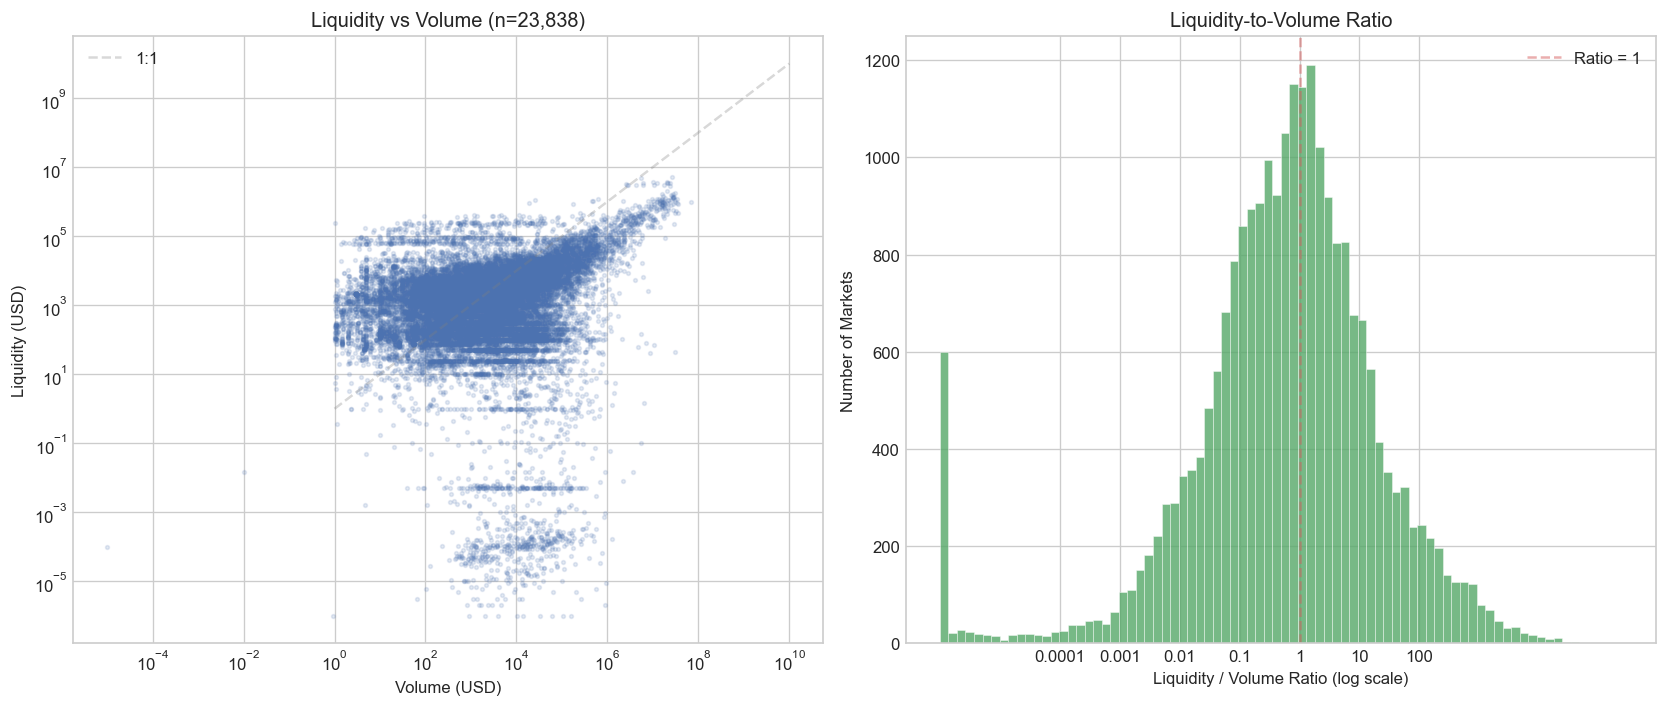

Median liq/vol ratio: 0.7185
Markets with liquidity > volume: 10,752 (45.1%)


In [7]:
# Scatter: liquidity vs volume for active markets
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# All markets with volume > 0
ax = axes[0]
has_both = markets[(markets['volume'] > 0) & (markets['liquidity'] > 0)]
ax.scatter(has_both['volume'], has_both['liquidity'], s=5, alpha=0.15, color='#4C72B0')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Volume (USD)')
ax.set_ylabel('Liquidity (USD)')
ax.set_title(f'Liquidity vs Volume (n={len(has_both):,})')
ax.plot([1, 1e10], [1, 1e10], '--', color='gray', alpha=0.3, label='1:1')
ax.legend()

# Liquidity ratio distribution
ax = axes[1]
liq_ratio = has_both['liquidity'] / has_both['volume']
ax.hist(np.log10(liq_ratio.clip(1e-6, 1e6)), bins=80, color='#55A868', alpha=0.8, edgecolor='white', linewidth=0.3)
ax.set_xlabel('Liquidity / Volume Ratio (log scale)')
ax.set_ylabel('Number of Markets')
ax.set_title('Liquidity-to-Volume Ratio')
ax.axvline(0, color='#D65F5F', linestyle='--', alpha=0.5, label='Ratio = 1')
ax.set_xticks([-4, -3, -2, -1, 0, 1, 2])
ax.set_xticklabels(['0.0001', '0.001', '0.01', '0.1', '1', '10', '100'])
ax.legend()

plt.tight_layout()
plt.show()

print(f'Median liq/vol ratio: {liq_ratio.median():.4f}')
print(f'Markets with liquidity > volume: {(liq_ratio > 1).sum():,} ({100*(liq_ratio>1).mean():.1f}%)')

## 7. Win Rate by Price (Market Calibration)

Resolved token mappings: 783,744


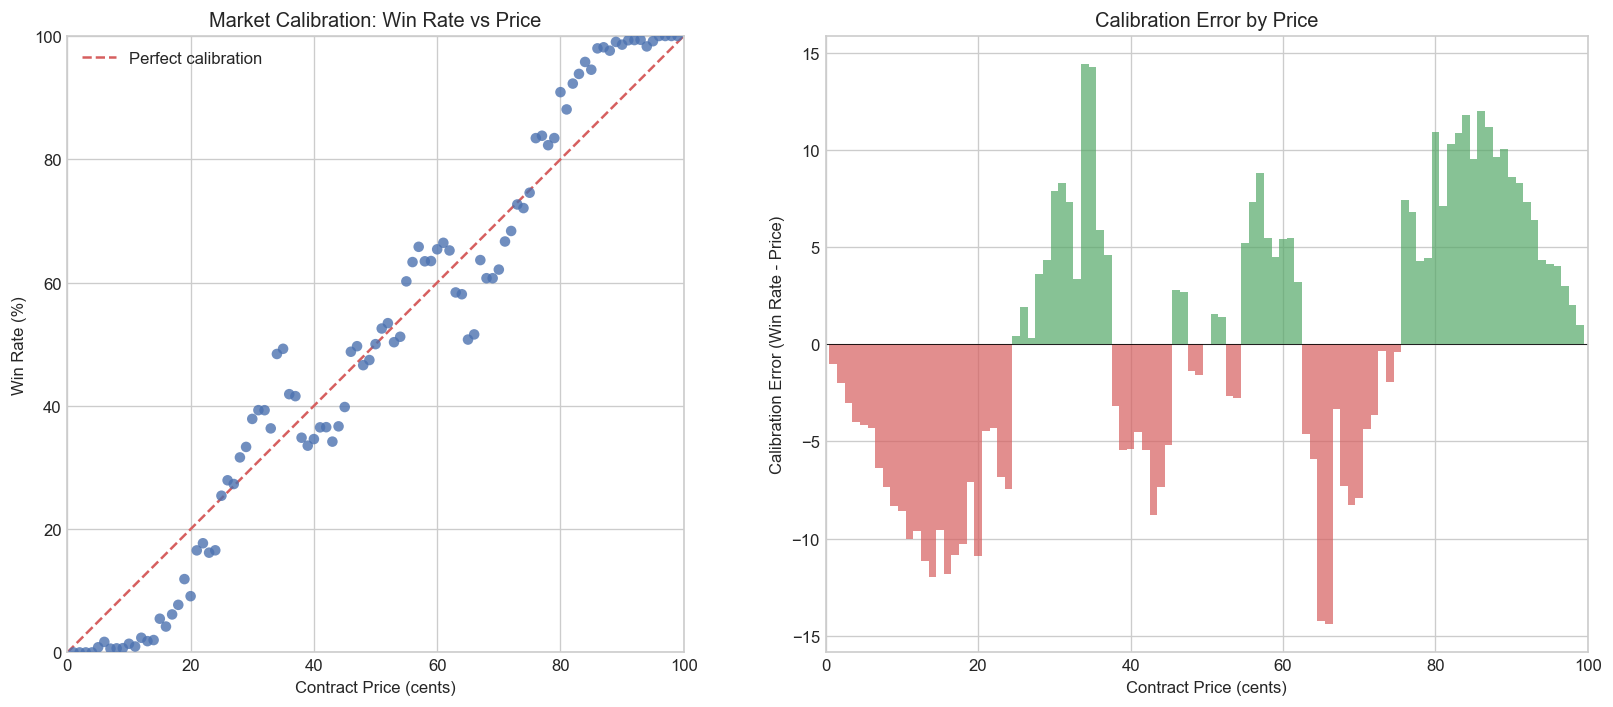


Calibration metrics (from 955,429 trade positions):
  Brier Score: 0.1706 (perfect=0, random=0.25, well-calibrated~0.17)
  ECE: 0.0574


In [8]:
# Build token resolution mapping
import math

token_won = {}
for _, row in markets[markets['closed'] == True].iterrows():
    try:
        prices = json.loads(row['outcome_prices']) if row['outcome_prices'] else None
        if not prices or len(prices) != 2:
            continue
        p0, p1 = float(prices[0]), float(prices[1])
        if p0 > 0.99 and p1 < 0.01:
            winning = 0
        elif p0 < 0.01 and p1 > 0.99:
            winning = 1
        else:
            continue
        token_ids = json.loads(row['clob_token_ids']) if row['clob_token_ids'] else None
        if token_ids and len(token_ids) == 2:
            token_won[token_ids[0]] = (winning == 0)
            token_won[token_ids[1]] = (winning == 1)
    except:
        continue

print(f'Resolved token mappings: {len(token_won):,}')

# Register in duckdb for join
con2 = duckdb.connect()
con2.execute('CREATE TABLE token_resolution (token_id VARCHAR, won BOOLEAN)')
con2.executemany('INSERT INTO token_resolution VALUES (?, ?)', list(token_won.items()))

# Join trades with resolution
calibration = con2.execute(f"""
    WITH trade_positions AS (
        SELECT
            CASE
                WHEN t.maker_asset_id = '0' THEN ROUND(100.0 * t.maker_amount / t.taker_amount)
                ELSE ROUND(100.0 * t.taker_amount / t.maker_amount)
            END AS price,
            tr.won
        FROM '{base / 'trades' / '*.parquet'}' t
        INNER JOIN token_resolution tr ON (
            CASE WHEN t.maker_asset_id = '0' THEN t.taker_asset_id ELSE t.maker_asset_id END = tr.token_id
        )
        WHERE t.taker_amount > 0 AND t.maker_amount > 0

        UNION ALL

        SELECT
            CASE
                WHEN t.maker_asset_id = '0' THEN ROUND(100.0 - 100.0 * t.maker_amount / t.taker_amount)
                ELSE ROUND(100.0 - 100.0 * t.taker_amount / t.maker_amount)
            END AS price,
            NOT tr.won AS won
        FROM '{base / 'trades' / '*.parquet'}' t
        INNER JOIN token_resolution tr ON (
            CASE WHEN t.maker_asset_id = '0' THEN t.taker_asset_id ELSE t.maker_asset_id END = tr.token_id
        )
        WHERE t.taker_amount > 0 AND t.maker_amount > 0
    )
    SELECT
        price,
        COUNT(*) AS total_trades,
        SUM(CASE WHEN won THEN 1 ELSE 0 END) AS wins,
        100.0 * SUM(CASE WHEN won THEN 1 ELSE 0 END) / COUNT(*) AS win_rate
    FROM trade_positions
    WHERE price >= 1 AND price <= 99
    GROUP BY price
    ORDER BY price
""").df()

# Plot calibration
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(calibration['price'], calibration['win_rate'], s=40, alpha=0.8, color='#4C72B0', edgecolors='none', zorder=3)
ax.plot([0, 100], [0, 100], '--', color='#D65F5F', linewidth=1.5, label='Perfect calibration')
ax.set_xlabel('Contract Price (cents)')
ax.set_ylabel('Win Rate (%)')
ax.set_title('Market Calibration: Win Rate vs Price')
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_aspect('equal')
ax.legend(loc='upper left')

# Calibration error by price
ax = axes[1]
calibration['error'] = calibration['win_rate'] - calibration['price']
colors = ['#55A868' if e >= 0 else '#D65F5F' for e in calibration['error']]
ax.bar(calibration['price'], calibration['error'], color=colors, alpha=0.7, width=1)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Contract Price (cents)')
ax.set_ylabel('Calibration Error (Win Rate - Price)')
ax.set_title('Calibration Error by Price')
ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

# Metrics
total_trades = calibration['total_trades'].sum()
brier_sum = sum(
    row['wins'] * (row['price']/100 - 1)**2 + (row['total_trades'] - row['wins']) * (row['price']/100)**2
    for _, row in calibration.iterrows()
)
brier = brier_sum / total_trades if total_trades > 0 else 0
ece = sum(
    row['total_trades'] * abs(row['win_rate']/100 - row['price']/100)
    for _, row in calibration.iterrows()
) / total_trades if total_trades > 0 else 0

print(f'\nCalibration metrics (from {total_trades:,} trade positions):')
print(f'  Brier Score: {brier:.4f} (perfect=0, random=0.25, well-calibrated~0.17)')
print(f'  ECE: {ece:.4f}')

## 8. Summary Statistics

In [9]:
print('=' * 60)
print('POLYMARKET DATA SUMMARY')
print('=' * 60)
print(f'\n--- Markets ---')
print(f'  Total markets:        {len(markets):>12,}')
print(f'  Closed markets:       {markets["closed"].sum():>12,}')
print(f'  Open markets:         {(~markets["closed"]).sum():>12,}')
print(f'  Total volume:         ${markets["volume"].sum():>15,.0f}')
print(f'  Median volume:        ${markets["volume"].median():>15,.0f}')
print(f'  Largest market:       ${markets["volume"].max():>15,.0f}')
print(f'  Zero-volume markets:  {(markets["volume"]==0).sum():>12,} ({100*(markets["volume"]==0).mean():.1f}%)')
print(f'  Date range:           {markets["created_at"].min().strftime("%Y-%m-%d")} to {markets["created_at"].max().strftime("%Y-%m-%d")}')
print(f'\n--- Trades (sample) ---')
print(f'  Total trades:         {len(trades):>12,}')
print(f'  Unique makers:        {trades["maker"].nunique():>12,}')
print(f'  Unique takers:        {trades["taker"].nunique():>12,}')
print(f'  CTF Exchange:         {(trades["_contract"]=="CTF Exchange").sum():>12,}')
print(f'  NegRisk Exchange:     {(trades["_contract"]=="NegRisk CTF Exchange").sum():>12,}')
print(f'  Block range:          {trades["block_number"].min():,} - {trades["block_number"].max():,}')
print(f'\n--- Data Coverage ---')
print(f'  Markets parquet files: {len(list((base / "markets").glob("*.parquet")))} files ({sum(f.stat().st_size for f in (base / "markets").glob("*.parquet")) / 1e6:.1f} MB)')
print(f'  Trades parquet files:  {len(list((base / "trades").glob("*.parquet")))} files ({sum(f.stat().st_size for f in (base / "trades").glob("*.parquet")) / 1e6:.1f} MB)')
print(f'\nNote: Trades are a partial snapshot (~70K from recent blocks).')
print(f'The full dataset (36 GiB compressed) can be downloaded with `make setup`.')

POLYMARKET DATA SUMMARY

--- Markets ---
  Total markets:             420,585
  Closed markets:            394,348
  Open markets:               26,237
  Total volume:         $ 50,569,939,969
  Median volume:        $          2,616
  Largest market:       $  1,531,479,285
  Zero-volume markets:        76,186 (18.1%)
  Date range:           2020-10-02 to 2026-02-11

--- Trades (sample) ---
  Total trades:              715,489
  Unique makers:              27,302
  Unique takers:              21,723
  CTF Exchange:              604,319
  NegRisk Exchange:          111,170
  Block range:          82,835,952 - 82,840,952

--- Data Coverage ---
  Markets parquet files: 43 files (109.6 MB)
  Trades parquet files:  72 files (83.9 MB)

Note: Trades are a partial snapshot (~70K from recent blocks).
The full dataset (36 GiB compressed) can be downloaded with `make setup`.
